In [1]:
from mpdaf.obj import Cube

cube = Cube('HH399_MUSE_WFM.fits')
cube

<Cube(shape=(3681, 317, 318), unit='1e-20 erg / (Angstrom s cm2)', dtype='None')>

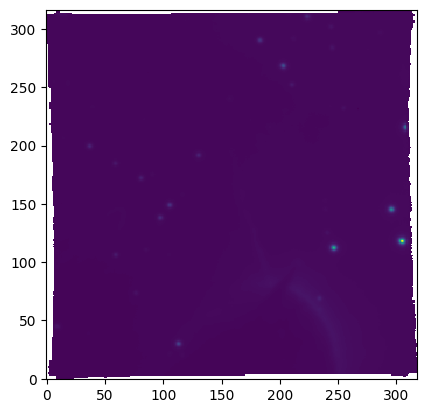

In [2]:
#White light image

white = cube.sum(axis=0)
white.plot()

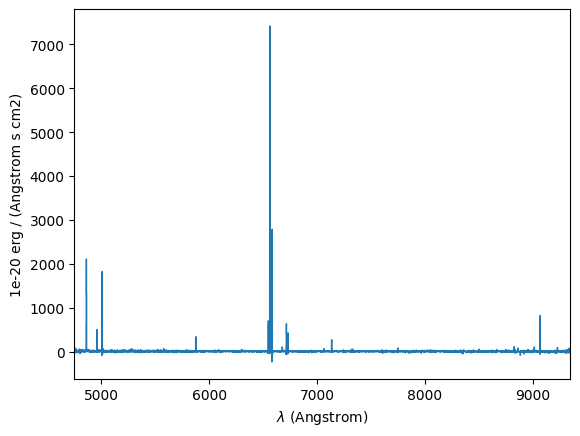

In [3]:
spec = cube[:, 150, 150]
spec.plot()

In [4]:
cube.wave.get_range()

array([4749.9921875, 9349.9921875])

In [5]:
from mpdaf.sdetect import SourceCatalog

white = cube.sum(axis=0)
cat = SourceCatalog(white, threshold=5)   # 5σ detection
cat.plot()


ImportError: cannot import name 'SourceCatalog' from 'mpdaf.sdetect' (C:\Users\ESHAN JAIN\.conda\envs\ml_env\lib\site-packages\mpdaf\sdetect\__init__.py)

In [6]:
import mpdaf
print(mpdaf.__version__)


3.6


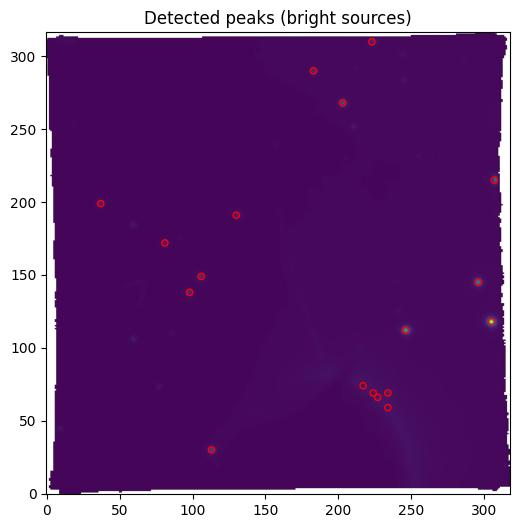

In [9]:
import numpy as np
from scipy.ndimage import maximum_filter, gaussian_filter
import matplotlib.pyplot as plt

white = cube.sum(axis=0)
data = white.data

# Smooth image to reduce noise
smooth = gaussian_filter(data, sigma=1)

# Find local maxima
neighborhood = maximum_filter(smooth, size=5)
peaks = (smooth == neighborhood) & (smooth > np.percentile(smooth, 99.5))

y, x = np.where(peaks)

plt.figure(figsize=(6,6))
plt.imshow(data, origin='lower', cmap='viridis')
plt.scatter(x, y, s=20, edgecolor='red', facecolor='none')
plt.title("Detected peaks (bright sources)")
plt.show()




In [10]:
spectra = []

for xi, yi in zip(x, y):
    spec = cube[:, yi, xi]
    spectra.append((xi, yi, spec))


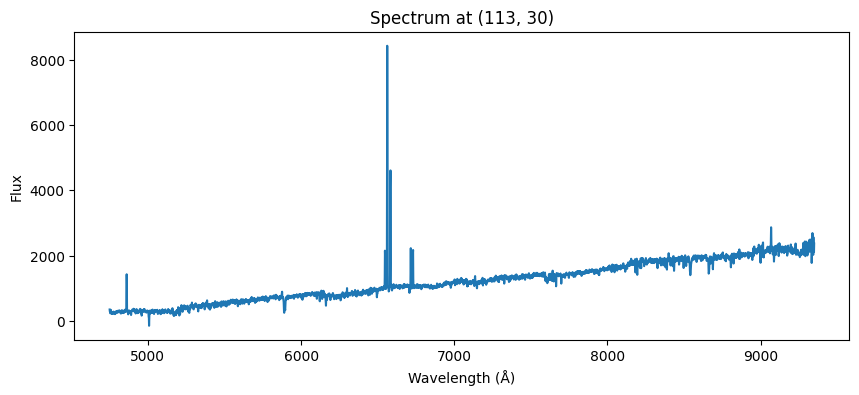

In [13]:
# Convert WaveCoord → numpy array
wave = spec.wave.coord(pixel=np.arange(spec.shape[0]))
flux = spec.data.filled(0)

plt.figure(figsize=(10,4))
plt.plot(wave, flux)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.title(f"Spectrum at ({xi}, {yi})")
plt.show()




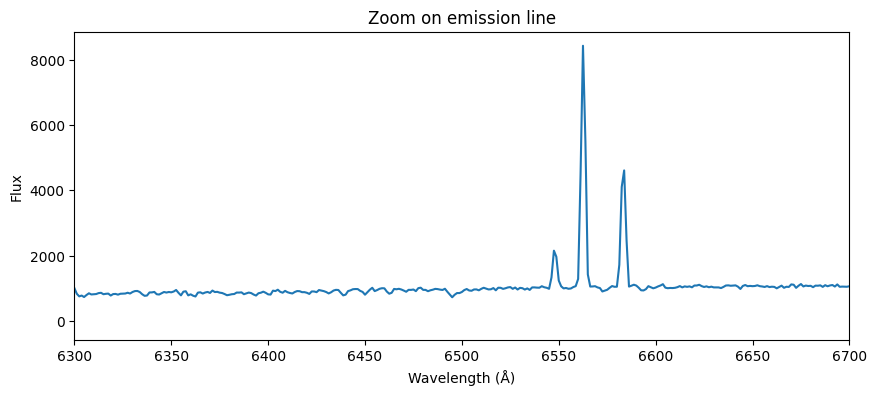

In [14]:
plt.figure(figsize=(10,4))
plt.plot(wave, flux)
plt.xlim(6300, 6700)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.title("Zoom on emission line")
plt.show()


In [15]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(flux, height=np.percentile(flux, 99))
print(wave[peaks])


[6562.4921875 6583.7421875 9016.2421875 9068.7421875 9112.4921875
 9122.4921875 9124.9921875 9197.4921875 9228.7421875 9278.7421875
 9288.7421875 9297.4921875 9299.9921875 9313.7421875 9316.2421875
 9318.7421875 9321.2421875 9323.7421875 9327.4921875 9338.7421875
 9341.2421875 9344.9921875]


C:\Users\ESHAN JAIN\.conda\envs\ml_env\lib\site-packages\mpdaf\obj\objs.py:211: RuntimeWarning: invalid value encountered in cast
  c = np.where(iseven, np.floor(center), np.floor(center + 0.5)).astype(int)
[WARNING] The world coordinates and data have different dimensions. Modifying the shape of the WCS object
C:\Users\ESHAN JAIN\.conda\envs\ml_env\lib\site-packages\mpdaf\obj\cube.py:1882: RuntimeWarning: overflow encountered in scalar subtract
  shape = (sl.stop - sl.start, uy.stop - uy.start, ux.stop - ux.start)
[INFO] 225 spaxels used


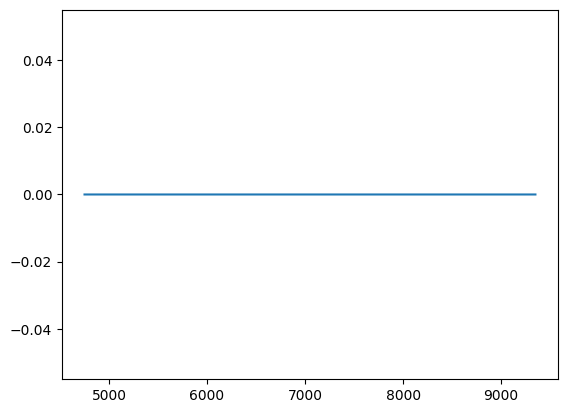

In [16]:
spec_ap = cube.aperture((yi, xi), radius=1.5)  # radius in pixels
wave = spec_ap.wave.coord(pixel=np.arange(spec_ap.shape[0]))
flux = spec_ap.data.filled(0)

plt.plot(wave, flux)


In [18]:
from scipy.signal import find_peaks
import numpy as np

peaks, props = find_peaks(flux, height=np.max(flux)*0.3)  # 30% of max
print("Peak wavelengths:", wave[peaks])
print("Peak heights:", props["peak_heights"])


Peak wavelengths: []
Peak heights: []


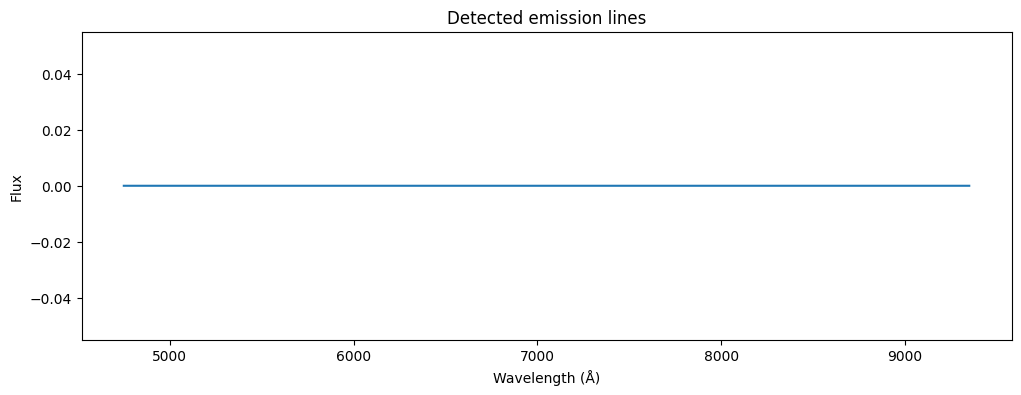

In [19]:
plt.figure(figsize=(12,4))
plt.plot(wave, flux)
plt.scatter(wave[peaks], flux[peaks], color='red', s=50)
plt.title("Detected emission lines")
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux")
plt.show()


In [20]:
print(flux.min(), flux.max())


0.0 0.0


In [21]:
print(flux.min(), flux.max())



0.0 0.0


In [22]:
print(spec.data.min(), spec.data.max())


-153.9138946533203 8433.5966796875


In [23]:
import numpy as np

idx_main = np.argmax(flux)
lam_main = wave[idx_main]
print("Main line wavelength:", lam_main)


Main line wavelength: 4749.9921875


In [24]:
xi, yi = 115, 50   # or whichever bright pixel you used

spec = cube[:, yi, xi]
wave = spec.wave.coord(pixel=np.arange(spec.shape[0]))
flux = spec.data.filled(0)

print(flux.min(), flux.max())


-108.52461242675781 8787.279296875


In [25]:
idx_main = np.argmax(flux)
lam_main = wave[idx_main]
print("Main line wavelength:", lam_main)


Main line wavelength: 6562.4921875


In [8]:
import numpy as np

# Get wavelength array in Angstroms (mpdaf default)
wave_arr = cube.wave.coord()   # shape (3681,) in Angstroms
step = wave_arr[1] - wave_arr[0]  # calculate step directly from array

print(f"Wavelength range: {wave_arr[0]:.1f} – {wave_arr[-1]:.1f} Å")
print(f"Step per channel: {step:.4f} Å/channel")
print(f"Total channels:   {len(wave_arr)}")

Wavelength range: 4750.0 – 9350.0 Å
Step per channel: 1.2500 Å/channel
Total channels:   3681


In [9]:
# Hα rest wavelength in Angstroms (mpdaf works in Angstroms)
Ha_wave = 6563.0   # Å

# Define a window ±5 Å around the line
window = 5.0
Ha_min = Ha_wave - window   # 6558 Å
Ha_max = Ha_wave + window   # 6568 Å

# Convert wavelengths to channel indices
chan_min = cube.wave.pixel(Ha_min, nearest=True)
chan_max = cube.wave.pixel(Ha_max, nearest=True)

print(f"Hα window: {Ha_min}–{Ha_max} Å")
print(f"Channel indices: {chan_min} to {chan_max}")

Hα window: 6558.0–6568.0 Å
Channel indices: 1446 to 1454


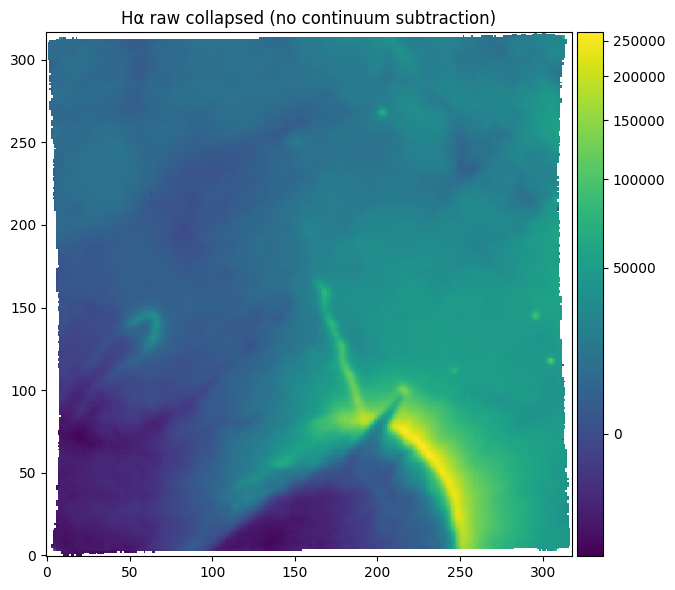

In [10]:
# Sum over the Hα channels → 2D image
Ha_slice = cube[chan_min:chan_max+1, :, :]   # mpdaf sub-cube
Ha_map_raw = Ha_slice.sum(axis=0)            # collapses wavelength axis → Image object

# Quick look
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 6))
Ha_map_raw.plot(scale='arcsinh', colorbar='v', ax=ax)
ax.set_title('Hα raw collapsed (no continuum subtraction)')
plt.tight_layout()
plt.show()

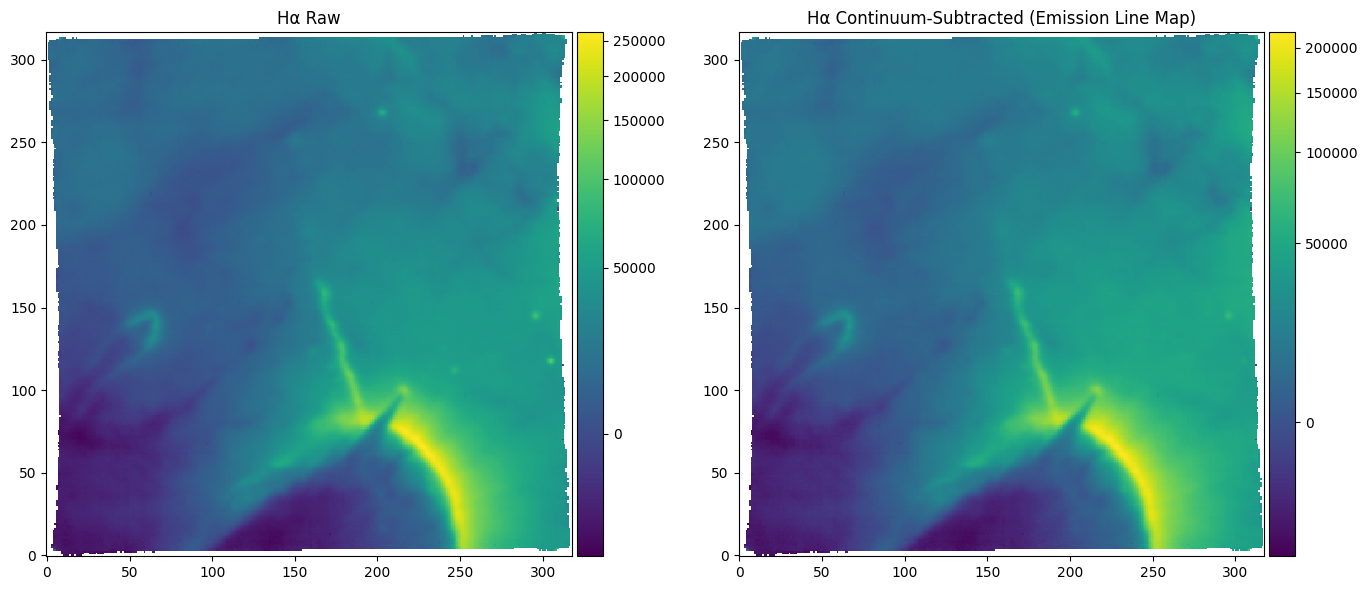

In [11]:
# Define continuum windows either side of the line (same width as line window)
cont_width = 15.0   # Å per side

blue_min = cube.wave.pixel(Ha_min - cont_width, nearest=True)
blue_max = cube.wave.pixel(Ha_min,              nearest=True)
red_min  = cube.wave.pixel(Ha_max,              nearest=True)
red_max  = cube.wave.pixel(Ha_max + cont_width, nearest=True)

# Collapse continuum on both sides
cont_blue = cube[blue_min:blue_max+1, :, :].sum(axis=0)
cont_red  = cube[red_min :red_max+1,  :, :].sum(axis=0)

# Average continuum and scale to the same number of channels as line window
n_line = chan_max - chan_min + 1
n_cont = ((blue_max - blue_min) + (red_max - red_min)) / 2.0

cont_estimate = ((cont_blue + cont_red) * (n_line / (2 * n_cont)))

# Subtract continuum
Ha_map = Ha_map_raw - cont_estimate

# Final plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
Ha_map_raw.plot(scale='arcsinh', colorbar='v', ax=axes[0])
axes[0].set_title('Hα Raw')
Ha_map.plot(scale='arcsinh', colorbar='v', ax=axes[1])
axes[1].set_title('Hα Continuum-Subtracted (Emission Line Map)')
plt.tight_layout()
plt.show()

## [N II] — 6583 Å


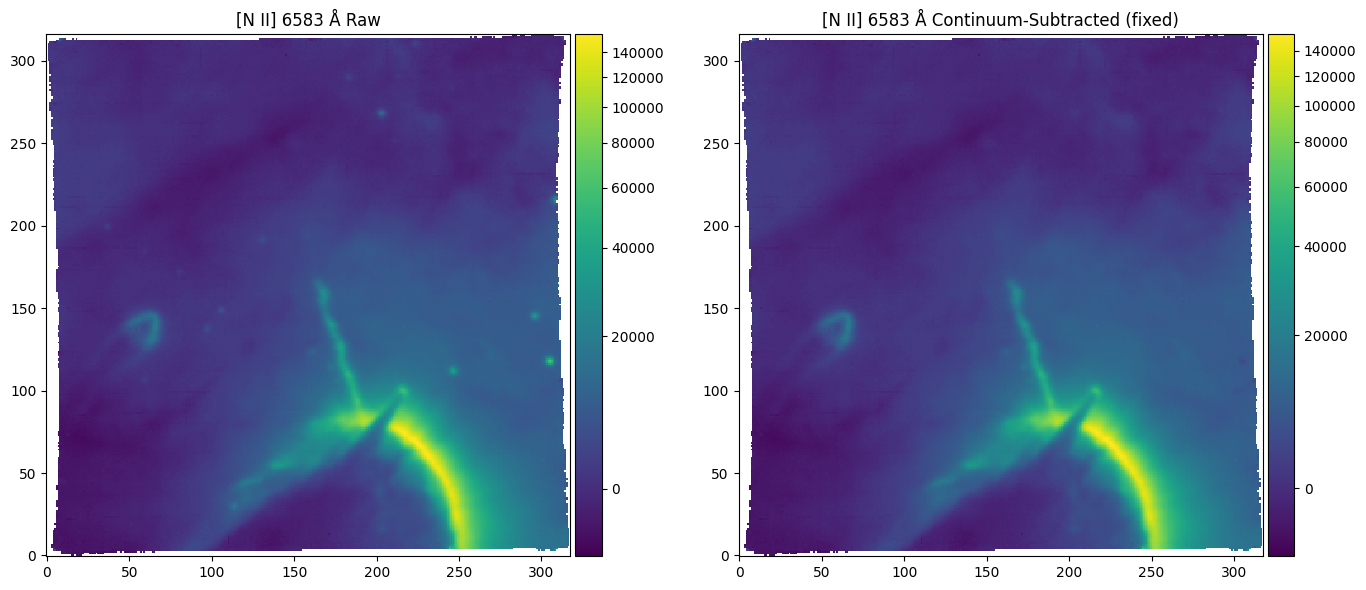

In [16]:
# [N II] 6583 Å — push blue continuum window past Hα
NII_wave = 6583.0
window = 5.0
cont_width = 15.0

chan_min_NII = cube.wave.pixel(NII_wave - window, nearest=True)
chan_max_NII = cube.wave.pixel(NII_wave + window, nearest=True)

NII_map_raw = cube[chan_min_NII:chan_max_NII+1, :, :].sum(axis=0)

# Blue continuum: must skip over Hα at 6563 Å — start at 6540 Å
b_min = cube.wave.pixel(6530.0, nearest=True)
b_max = cube.wave.pixel(6545.0, nearest=True)

# Red continuum: safe on other side
r_min = cube.wave.pixel(NII_wave + window,              nearest=True)
r_max = cube.wave.pixel(NII_wave + window + cont_width, nearest=True)

cont_blue = cube[b_min:b_max+1, :, :].sum(axis=0)
cont_red  = cube[r_min:r_max+1, :, :].sum(axis=0)

n_line = chan_max_NII - chan_min_NII + 1
n_cont = ((b_max - b_min) + (r_max - r_min)) / 2.0
cont_estimate = (cont_blue + cont_red) * (n_line / (2 * n_cont))

NII_map = NII_map_raw - cont_estimate

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
NII_map_raw.plot(scale='arcsinh', colorbar='v', ax=axes[0])
axes[0].set_title('[N II] 6583 Å Raw')
NII_map.plot(scale='arcsinh', colorbar='v', ax=axes[1])
axes[1].set_title('[N II] 6583 Å Continuum-Subtracted (fixed)')
plt.tight_layout()
plt.show()

## [S II] — 6716 Å & 6731 Å

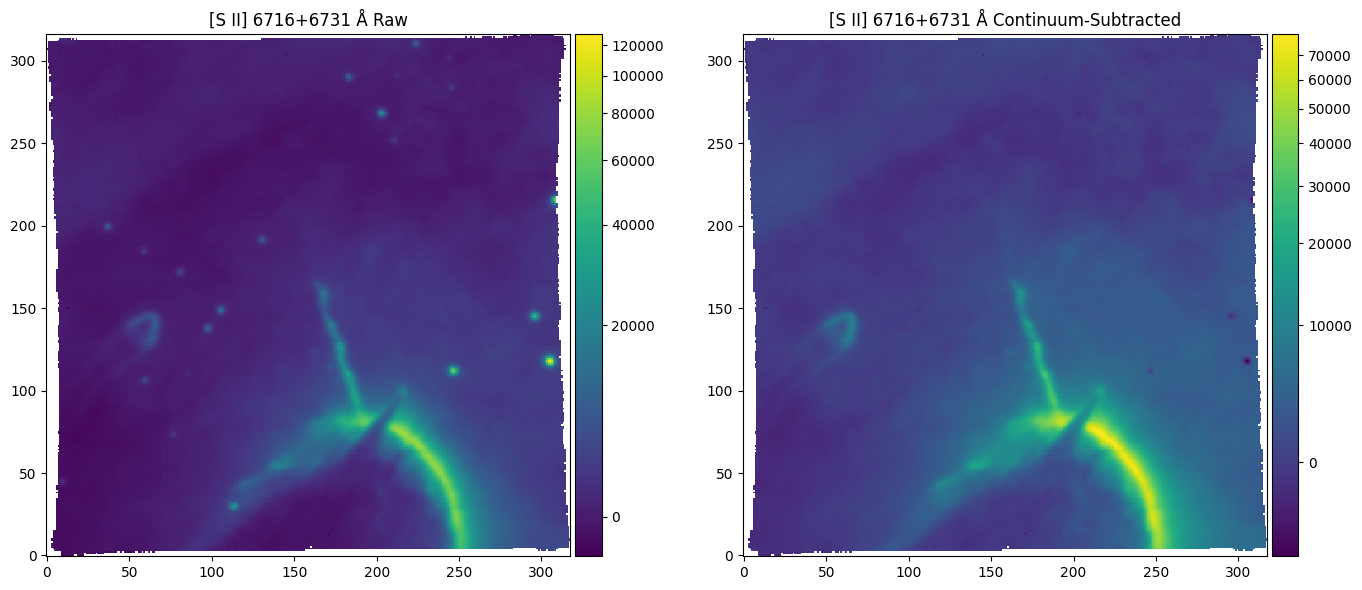

In [13]:
# [S II] doublet 6716+6731 Å — map both lines together
import matplotlib.pyplot as plt

SII_wave_1 = 6716.0
SII_wave_2 = 6731.0
window = 5.0

# Use a wide window spanning both lines of the doublet
chan_min_SII = cube.wave.pixel(SII_wave_1 - window, nearest=True)
chan_max_SII = cube.wave.pixel(SII_wave_2 + window, nearest=True)

# Collapse line channels
SII_map_raw = cube[chan_min_SII:chan_max_SII+1, :, :].sum(axis=0)

# Continuum windows either side of the doublet
cont_width = 15.0
b_min = cube.wave.pixel(SII_wave_1 - window - cont_width, nearest=True)
b_max = cube.wave.pixel(SII_wave_1 - window, nearest=True)
r_min = cube.wave.pixel(SII_wave_2 + window, nearest=True)
r_max = cube.wave.pixel(SII_wave_2 + window + cont_width, nearest=True)

cont_blue = cube[b_min:b_max+1, :, :].sum(axis=0)
cont_red  = cube[r_min:r_max+1, :, :].sum(axis=0)

n_line = chan_max_SII - chan_min_SII + 1
n_cont = ((b_max - b_min) + (r_max - r_min)) / 2.0
cont_estimate = (cont_blue + cont_red) * (n_line / (2 * n_cont))

SII_map = SII_map_raw - cont_estimate

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
SII_map_raw.plot(scale='arcsinh', colorbar='v', ax=axes[0])
axes[0].set_title('[S II] 6716+6731 Å Raw')
SII_map.plot(scale='arcsinh', colorbar='v', ax=axes[1])
axes[1].set_title('[S II] 6716+6731 Å Continuum-Subtracted')
plt.tight_layout()
plt.show()

## [O III] — 5007 Å

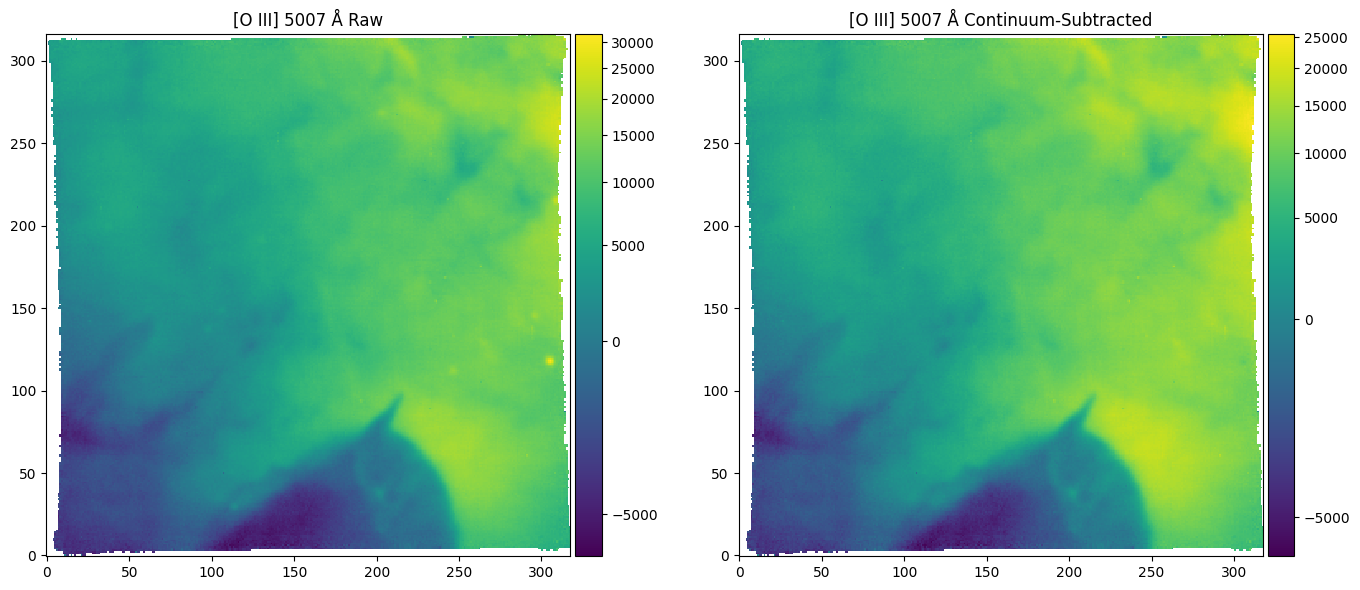

In [15]:
# [O III] 5007 Å emission line map
OIII_wave = 5007.0
window = 5.0

chan_min_OIII = cube.wave.pixel(OIII_wave - window, nearest=True)
chan_max_OIII = cube.wave.pixel(OIII_wave + window, nearest=True)

# Collapse line channels
OIII_map_raw = cube[chan_min_OIII:chan_max_OIII+1, :, :].sum(axis=0)

# Continuum windows either side
cont_width = 15.0
b_min = max(0, b_min)  # clamp to cube edge
b_min = cube.wave.pixel(OIII_wave - window - cont_width, nearest=True)
b_max = cube.wave.pixel(OIII_wave - window, nearest=True)
r_min = cube.wave.pixel(OIII_wave + window, nearest=True)
r_max = cube.wave.pixel(OIII_wave + window + cont_width, nearest=True)

cont_blue = cube[b_min:b_max+1, :, :].sum(axis=0)
cont_red  = cube[r_min:r_max+1, :, :].sum(axis=0)

n_line = chan_max_OIII - chan_min_OIII + 1
n_cont = ((b_max - b_min) + (r_max - r_min)) / 2.0
cont_estimate = (cont_blue + cont_red) * (n_line / (2 * n_cont))

OIII_map = OIII_map_raw - cont_estimate

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
OIII_map_raw.plot(scale='arcsinh', colorbar='v', ax=axes[0])
axes[0].set_title('[O III] 5007 Å Raw')
OIII_map.plot(scale='arcsinh', colorbar='v', ax=axes[1])
axes[1].set_title('[O III] 5007 Å Continuum-Subtracted')
plt.tight_layout()
plt.show()

## Clip Archietecure by OPENAI

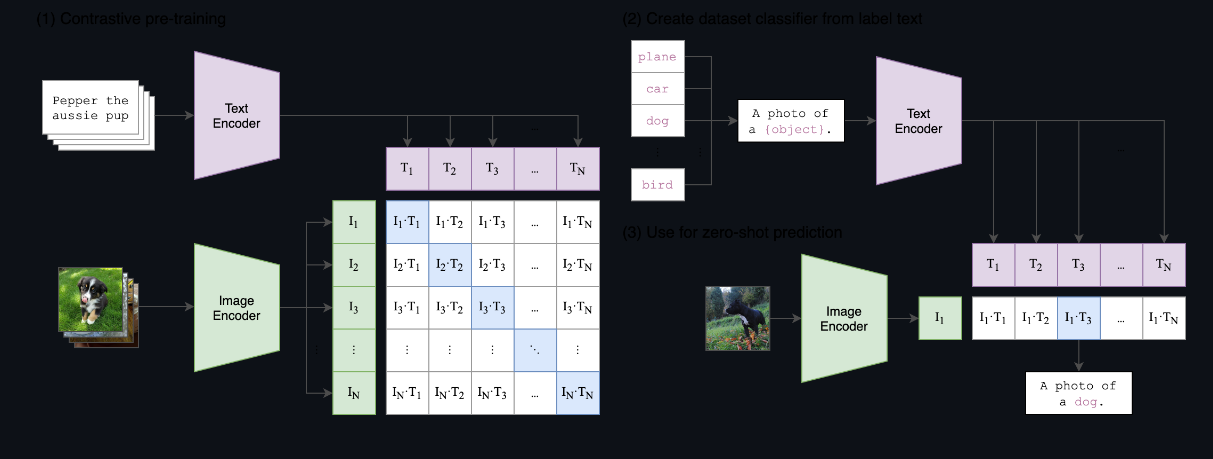


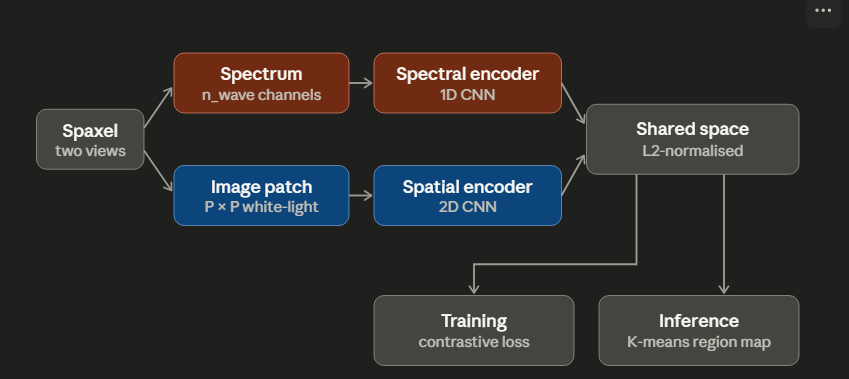



A CLIP-style contrastive model adapted for a **single** MUSE integral-field cube.

## Idea

CLIP aligns two views of the same thing (image + caption) in one embedding space. A MUSE cube already gives you two views of every spaxel:

1. its **spectrum** — what kind of physics is here (lines, ratios)
2. its **spatial neighbourhood** — what kind of structure is here (point source, filament, diffuse gas), as a small image patch

We train a spectral encoder and a spatial encoder so that a spaxel's spectrum sits close to its own image patch and far from the patches of *other* spaxels in the batch (the symmetric InfoNCE / CLIP loss). No labels required.

The payoff: after training you can embed every spaxel and cluster the embeddings into an unsupervised "region map" of the field — a data-driven complement to the hand-built emission-line maps.

Both spectra and patches are standardised per-example, so the model is forced to align *spectral shape* with *spatial morphology* rather than taking the trivial shortcut of matching total brightness to total brightness.

## Usage in the notebook

```python
from mpdaf.obj import Cube
from clip_muse import load_cube_data, MuseSpaxelPairs, SpectralSpatialCLIP, train, segment_cube

cube_data = load_cube_data("HH399_MUSE_WFM.fits")     # (n_wave, ny, nx) float array
pairs = MuseSpaxelPairs(cube_data, patch=11)
model = SpectralSpatialCLIP(n_wave=pairs.nw, patch=pairs.patch, dim=128)
train(model, pairs, steps=2000, batch_size=256)
labels = segment_cube(model, pairs, k=6)              # (ny, nx) int map, -1 = masked
```

**Requires:** numpy, torch, scikit-learn (matplotlib only for the optional plot).

In [1]:
from __future__ import annotations
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
def load_cube_data(path: str) -> np.ndarray:
    """Read a MUSE cube with mpdaf and return a (n_wave, ny, nx) float32 array
    with bad/masked pixels set to NaN. Decoupled from the rest of the module so
    the model code has no mpdaf dependency."""
    from mpdaf.obj import Cube
    cube = Cube(path)
    data = np.ma.filled(cube.data.astype("float32"), np.nan)
    return np.asarray(data, dtype=np.float32)

In [3]:
class MuseSpaxelPairs:
    """Builds (spectrum, image-patch) training pairs from one cube.
 
    Parameters
    ----------
    cube_data : (n_wave, ny, nx) array, NaN for bad pixels
    patch     : odd int, side length of the square image patch (default 11)
    min_finite: spaxel is usable only if at least this fraction of its spectral
                channels are finite
    """
 
    def __init__(self, cube_data: np.ndarray, patch: int = 11, min_finite: float = 0.9):
        assert patch % 2 == 1, "patch must be odd so it can be centred on a spaxel"
        self.cube = np.asarray(cube_data, dtype=np.float32)
        self.nw, self.ny, self.nx = self.cube.shape
        self.patch = patch
        self.r = patch // 2
 
        # white-light image (collapse wavelength, ignore NaN), reflect-padded so
        # every spaxel -- including edges -- has a full patch.
        white = np.nansum(self.cube, axis=0).astype(np.float32)
        self.white_pad = np.pad(white, self.r, mode="reflect")
 
        # validity mask: keep spaxels whose spectra are mostly finite
        frac_finite = np.isfinite(self.cube).mean(axis=0)
        self.valid = np.argwhere(frac_finite >= min_finite).astype(np.int64)  # (M, 2)
        if len(self.valid) == 0:
            raise ValueError("No valid spaxels found -- check the cube / min_finite.")
 
    def __len__(self) -> int:
        return len(self.valid)
 
    @staticmethod
    def _standardise(a: np.ndarray, axis) -> np.ndarray:
        mu = a.mean(axis=axis, keepdims=True)
        sd = a.std(axis=axis, keepdims=True) + 1e-6
        return (a - mu) / sd
 
    def _gather(self, ys: np.ndarray, xs: np.ndarray):
        # spectra: (B, n_wave)
        spec = self.cube[:, ys, xs].T.copy()          # (B, n_wave)
        spec = np.nan_to_num(spec, nan=0.0)
        spec = self._standardise(spec, axis=1)         # per-spectrum shape only
 
        # patches: (B, P, P)  -- vectorised window gather from the padded image
        P = self.patch
        patches = np.empty((len(ys), P, P), dtype=np.float32)
        for b, (y, x) in enumerate(zip(ys, xs)):
            patches[b] = self.white_pad[y:y + P, x:x + P]
        patches = self._standardise(patches.reshape(len(ys), -1), axis=1).reshape(-1, P, P)
        return spec, patches
 
    def sample_batch(self, n: int, device="cpu"):
        """Random batch of n distinct spaxels -> (spec, patch) torch tensors."""
        idx = np.random.choice(len(self.valid), size=n, replace=False)
        ys, xs = self.valid[idx, 0], self.valid[idx, 1]
        spec, patch = self._gather(ys, xs)
        return (torch.from_numpy(spec).to(device),
                torch.from_numpy(patch).to(device))
 
    def iter_all(self, batch_size: int, device="cpu"):
        """Yield (coords, spec, patch) over every valid spaxel once (for inference)."""
        for s in range(0, len(self.valid), batch_size):
            coords = self.valid[s:s + batch_size]
            spec, patch = self._gather(coords[:, 0], coords[:, 1])
            yield (coords,
                   torch.from_numpy(spec).to(device),
                   torch.from_numpy(patch).to(device))

## Encoders + clip model

In [4]:
class SpectralEncoder(nn.Module):
    """1D CNN over the wavelength axis -> embedding."""
 
    def __init__(self, n_wave: int, dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 32, 7, stride=2, padding=3), nn.GELU(),
            nn.Conv1d(32, 64, 7, stride=2, padding=3), nn.GELU(),
            nn.Conv1d(64, 128, 5, stride=2, padding=2), nn.GELU(),
            nn.Conv1d(128, 128, 5, stride=2, padding=2), nn.GELU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.proj = nn.Linear(128, dim)
 
    def forward(self, x):                 # x: (B, n_wave)
        h = self.net(x.unsqueeze(1)).squeeze(-1)   # (B, 128)
        return self.proj(h)
 
 
class SpatialEncoder(nn.Module):
    """Small 2D CNN over the white-light image patch -> embedding."""
 
    def __init__(self, patch: int, dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.GELU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.GELU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.GELU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.proj = nn.Linear(64, dim)
 
    def forward(self, x):                 # x: (B, P, P)
        h = self.net(x.unsqueeze(1)).flatten(1)    # (B, 64)
        return self.proj(h)

In [5]:
class SpectralSpatialCLIP(nn.Module):
    """Two encoders + a learnable temperature, aligned by the CLIP loss."""
 
    def __init__(self, n_wave: int, patch: int, dim: int = 128):
        super().__init__()
        self.spec_enc = SpectralEncoder(n_wave, dim)
        self.img_enc = SpatialEncoder(patch, dim)
        # logit scale, initialised at 1/0.07 like the original CLIP
        self.logit_scale = nn.Parameter(torch.tensor(np.log(1 / 0.07), dtype=torch.float32))
 
    def encode_spec(self, spec):
        return F.normalize(self.spec_enc(spec), dim=-1)
 
    def encode_img(self, patch):
        return F.normalize(self.img_enc(patch), dim=-1)
 
    def forward(self, spec, patch):
        s = self.encode_spec(spec)
        i = self.encode_img(patch)
        scale = self.logit_scale.exp().clamp(max=100.0)
        logits = scale * s @ i.t()        # (B, B) similarity matrix
        return logits
 
 
def clip_loss(logits: torch.Tensor) -> torch.Tensor:
    """Symmetric InfoNCE: the diagonal (true pairs) should win each row & column."""
    targets = torch.arange(logits.size(0), device=logits.device)
    return 0.5 * (F.cross_entropy(logits, targets) +
                  F.cross_entropy(logits.t(), targets))

## Training + Segmentation

In [6]:
def train(model, pairs, steps=2000, batch_size=256, lr=1e-3, device="cpu", log_every=200):
    model.to(device).train()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    bs = min(batch_size, len(pairs))
    history = []
    for step in range(1, steps + 1):
        spec, patch = pairs.sample_batch(bs, device=device)
        logits = model(spec, patch)
        loss = clip_loss(logits)
        opt.zero_grad()
        loss.backward()
        opt.step()
        history.append(loss.item())
        if step % log_every == 0 or step == 1:
            # batch retrieval accuracy = how often the true patch is the argmax
            with torch.no_grad():
                acc = (logits.argmax(dim=1) ==
                       torch.arange(logits.size(0), device=device)).float().mean().item()
            print(f"step {step:5d} | loss {loss.item():.4f} | batch top-1 {acc:.3f}")
    return history

In [7]:
@torch.no_grad()
def embed_all_spaxels(model, pairs, which="spec", batch_size=512, device="cpu"):
    """Embed every valid spaxel. Returns (coords (M,2), embeddings (M,dim))."""
    model.to(device).eval()
    coords_all, emb_all = [], []
    for coords, spec, patch in pairs.iter_all(batch_size, device=device):
        if which == "spec":
            e = model.encode_spec(spec)
        elif which == "img":
            e = model.encode_img(patch)
        else:  # concatenate both views
            e = torch.cat([model.encode_spec(spec), model.encode_img(patch)], dim=-1)
        coords_all.append(coords)
        emb_all.append(e.cpu().numpy())
    return np.concatenate(coords_all), np.concatenate(emb_all)
 
 

In [8]:
def segment_cube(model, pairs, k=6, which="spec", device="cpu", random_state=0):
    """Cluster spaxel embeddings into k regions; return a (ny, nx) label map
    with -1 marking masked / invalid spaxels."""
    from sklearn.cluster import KMeans
    coords, emb = embed_all_spaxels(model, pairs, which=which, device=device)
    labels = KMeans(n_clusters=k, n_init=10, random_state=random_state).fit_predict(emb)
    out = np.full((pairs.ny, pairs.nx), -1, dtype=np.int32)
    out[coords[:, 0], coords[:, 1]] = labels
    return out

In [9]:
def plot_segmentation(label_map, title="CLIP region map"):
    """Optional helper: show the segmentation with masked spaxels greyed out."""
    import matplotlib.pyplot as plt
    masked = np.ma.masked_where(label_map < 0, label_map)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(masked, origin="lower", cmap="tab10", interpolation="nearest")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="cluster", fraction=0.046)
    plt.tight_layout()
    return fig, ax

## Testing 

In [10]:
def _make_synthetic_cube(nw=400, ny=48, nx=48, n_regions=3, seed=0):
    """A toy cube with a few spectral 'archetypes' laid out in spatial blobs,
    so there is real structure for the model to recover."""
    rng = np.random.default_rng(seed)
    wave = np.linspace(0, 1, nw)
    # build distinct spectral templates (different emission-line positions)
    templates = []
    for r in range(n_regions):
        t = 0.2 * rng.standard_normal(nw) * 0  # start flat
        t = np.zeros(nw)
        for centre in rng.uniform(0.1, 0.9, size=2 + r):
            t += np.exp(-0.5 * ((wave - centre) / 0.01) ** 2)
        templates.append(t)
    # spatial region label per spaxel: a few Gaussian blobs
    centres = rng.uniform(0, 1, size=(n_regions, 2))
    yy, xx = np.mgrid[0:ny, 0:nx] / max(ny, nx)
    dist = np.stack([((yy - cy) ** 2 + (xx - cx) ** 2) for cy, cx in centres], axis=0)
    region = dist.argmin(axis=0)            # (ny, nx)
    cube = np.empty((nw, ny, nx), dtype=np.float32)
    for y in range(ny):
        for x in range(nx):
            amp = rng.uniform(0.5, 2.0)
            noise = 0.15 * rng.standard_normal(nw)
            cube[:, y, x] = amp * templates[region[y, x]] + noise
    # mask a border ring to mimic real MUSE edges
    cube[:, :2, :] = np.nan
    cube[:, -2:, :] = np.nan
    cube[:, :, :2] = np.nan
    cube[:, :, -2:] = np.nan
    return cube, region
 
 
if __name__ == "__main__":
    torch.manual_seed(0)
    np.random.seed(0)
    cube, true_region = _make_synthetic_cube()
    print(f"synthetic cube: {cube.shape} (n_wave, ny, nx)")
    pairs = MuseSpaxelPairs(cube, patch=11)
    print(f"valid spaxels: {len(pairs)}")
    model = SpectralSpatialCLIP(n_wave=pairs.nw, patch=pairs.patch, dim=64)
    hist = train(model, pairs, steps=600, batch_size=256, log_every=150)
    labels = segment_cube(model, pairs, k=3)
 
    # cluster vs. ground-truth agreement (adjusted Rand index, label-permutation safe)
    from sklearn.metrics import adjusted_rand_score
    m = labels >= 0
    ari = adjusted_rand_score(true_region[m], labels[m])
    print(f"final loss {hist[-1]:.4f} | recovered-region ARI {ari:.3f} (1.0 = perfect)")

synthetic cube: (400, 48, 48) (n_wave, ny, nx)
valid spaxels: 1936
step     1 | loss 5.5457 | batch top-1 0.004
step   150 | loss 4.7378 | batch top-1 0.027
step   300 | loss 4.5064 | batch top-1 0.023
step   450 | loss 4.1606 | batch top-1 0.094
step   600 | loss 2.4880 | batch top-1 0.348
final loss 2.4880 | recovered-region ARI 0.935 (1.0 = perfect)


In [12]:
import os
print(os.getcwd())
print([f for f in os.listdir() if f.endswith(".py")])

C:\Users\ESHAN JAIN\Data Science Muse project
[]


type(cube): ndarray | cube_data shape: (400, 48, 48)
valid spaxels: 1936
step     1 | loss 5.5457 | batch top-1 0.004
step   200 | loss 4.7363 | batch top-1 0.012
step   400 | loss 4.2849 | batch top-1 0.066
step   600 | loss 2.4880 | batch top-1 0.348
step   800 | loss 0.3766 | batch top-1 0.926
step  1000 | loss 0.0967 | batch top-1 0.996
step  1200 | loss 0.0568 | batch top-1 0.996
step  1400 | loss 0.0221 | batch top-1 1.000
step  1600 | loss 0.0314 | batch top-1 0.996
step  1800 | loss 0.0367 | batch top-1 0.996
step  2000 | loss 0.0045 | batch top-1 1.000


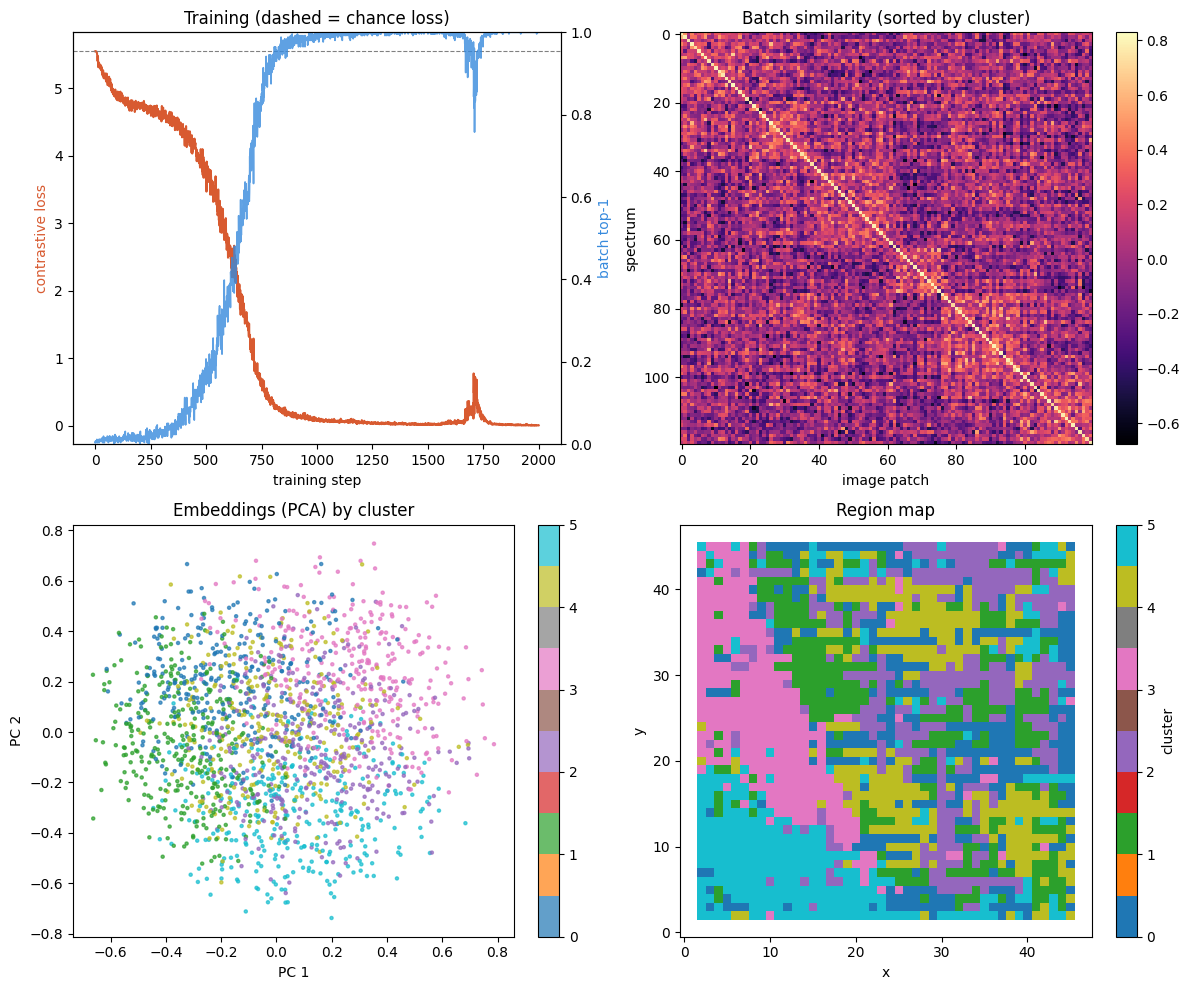

In [18]:
import numpy as np, torch
import torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 0. get the 3D data array, however `cube` was loaded
if hasattr(cube, "wave"):
    arr = cube.data
else:
    arr = cube
cube_data = np.ma.filled(np.ma.asarray(arr).astype("float32"), np.nan)
print("type(cube):", type(cube).__name__, "| cube_data shape:", cube_data.shape)

# 1. dataset
class MuseSpaxelPairs:
    def __init__(self, cube_data, patch=11, min_finite=0.9):
        self.cube = np.asarray(cube_data, np.float32)
        self.nw, self.ny, self.nx = self.cube.shape
        self.patch, self.r = patch, patch // 2
        white = np.nansum(self.cube, 0).astype(np.float32)
        self.white_pad = np.pad(white, self.r, mode="reflect")
        frac = np.isfinite(self.cube).mean(0)
        self.valid = np.argwhere(frac >= min_finite).astype(np.int64)
    def __len__(self): return len(self.valid)
    @staticmethod
    def _std(a, axis):
        mu = a.mean(axis, keepdims=True); sd = a.std(axis, keepdims=True) + 1e-6
        return (a - mu) / sd
    def _gather(self, ys, xs):
        spec = self._std(np.nan_to_num(self.cube[:, ys, xs].T.copy(), nan=0.0), 1)
        P = self.patch
        patches = np.empty((len(ys), P, P), np.float32)
        for b, (y, x) in enumerate(zip(ys, xs)):
            patches[b] = self.white_pad[y:y+P, x:x+P]
        patches = self._std(patches.reshape(len(ys), -1), 1).reshape(-1, P, P)
        return spec, patches
    def sample_batch(self, n, device="cpu"):
        idx = np.random.choice(len(self.valid), n, replace=False)
        ys, xs = self.valid[idx, 0], self.valid[idx, 1]
        s, p = self._gather(ys, xs)
        return torch.from_numpy(s).to(device), torch.from_numpy(p).to(device)
    def iter_all(self, bs, device="cpu"):
        for s in range(0, len(self.valid), bs):
            c = self.valid[s:s+bs]
            sp, pa = self._gather(c[:, 0], c[:, 1])
            yield c, torch.from_numpy(sp).to(device), torch.from_numpy(pa).to(device)

# 2. encoders + CLIP model
class SpectralEncoder(nn.Module):
    def __init__(self, nw, dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 32, 7, 2, 3), nn.GELU(), nn.Conv1d(32, 64, 7, 2, 3), nn.GELU(),
            nn.Conv1d(64, 128, 5, 2, 2), nn.GELU(), nn.Conv1d(128, 128, 5, 2, 2), nn.GELU(),
            nn.AdaptiveAvgPool1d(1))
        self.proj = nn.Linear(128, dim)
    def forward(self, x): return self.proj(self.net(x.unsqueeze(1)).squeeze(-1))

class SpatialEncoder(nn.Module):
    def __init__(self, patch, dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1), nn.GELU(), nn.Conv2d(32, 64, 3, 1, 1), nn.GELU(),
            nn.Conv2d(64, 64, 3, 1, 1), nn.GELU(), nn.AdaptiveAvgPool2d(1))
        self.proj = nn.Linear(64, dim)
    def forward(self, x): return self.proj(self.net(x.unsqueeze(1)).flatten(1))

class SpectralSpatialCLIP(nn.Module):
    def __init__(self, nw, patch, dim=64):
        super().__init__()
        self.spec_enc = SpectralEncoder(nw, dim)
        self.img_enc = SpatialEncoder(patch, dim)
        self.logit_scale = nn.Parameter(torch.tensor(np.log(1 / 0.07), dtype=torch.float32))
    def encode_spec(self, x): return F.normalize(self.spec_enc(x), dim=-1)
    def encode_img(self, x): return F.normalize(self.img_enc(x), dim=-1)
    def forward(self, spec, patch):
        s, i = self.encode_spec(spec), self.encode_img(patch)
        return self.logit_scale.exp().clamp(max=100.0) * s @ i.t()

def clip_loss(logits):
    t = torch.arange(logits.size(0), device=logits.device)
    return 0.5 * (F.cross_entropy(logits, t) + F.cross_entropy(logits.t(), t))

# 3. build + train
pairs = MuseSpaxelPairs(cube_data, patch=11)
print("valid spaxels:", len(pairs))

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0); np.random.seed(0)
model = SpectralSpatialCLIP(pairs.nw, pairs.patch, dim=64).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

STEPS, BATCH = 2000, 256            # on CPU, lower STEPS to ~800 if it's slow
bs = min(BATCH, len(pairs))
loss_hist, acc_hist = [], []
model.train()
for step in range(1, STEPS + 1):
    spec, patch = pairs.sample_batch(bs, device)
    logits = model(spec, patch)
    loss = clip_loss(logits)
    opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        acc = (logits.argmax(1) == torch.arange(bs, device=device)).float().mean().item()
    loss_hist.append(loss.item()); acc_hist.append(acc)
    if step % 200 == 0 or step == 1:
        print(f"step {step:5d} | loss {loss.item():.4f} | batch top-1 {acc:.3f}")

# 4. embeddings, clustering, plots
K = 6
model.eval()
coords, embs = [], []
with torch.no_grad():
    for c, spec, patch in pairs.iter_all(512, device):
        coords.append(c); embs.append(model.encode_spec(spec).cpu().numpy())
coords = np.concatenate(coords); emb = np.concatenate(embs)
km = KMeans(K, n_init=10, random_state=0).fit(emb)
labels = km.labels_
pca = PCA(2).fit_transform(emb)
region_map = np.full((pairs.ny, pairs.nx), -1, int)
region_map[coords[:, 0], coords[:, 1]] = labels

with torch.no_grad():
    nb = min(120, len(pairs))
    spec_b, patch_b = pairs.sample_batch(nb, device)
    s = model.encode_spec(spec_b).cpu().numpy(); i = model.encode_img(patch_b).cpu().numpy()
order = np.argsort(km.predict(s)); sim = s[order] @ i[order].T

fig, ax = plt.subplots(2, 2, figsize=(12, 10))
a = ax[0, 0]; a.plot(loss_hist, color="#D85A30", lw=1.5)
a.set_xlabel("training step"); a.set_ylabel("contrastive loss", color="#D85A30")
a.axhline(np.log(bs), ls="--", color="grey", lw=0.8)
a2 = a.twinx(); a2.plot(acc_hist, color="#378ADD", lw=1.2, alpha=0.8)
a2.set_ylabel("batch top-1", color="#378ADD"); a2.set_ylim(0, 1)
a.set_title("Training (dashed = chance loss)")

a = ax[0, 1]; im = a.imshow(sim, cmap="magma")
a.set_title("Batch similarity (sorted by cluster)")
a.set_xlabel("image patch"); a.set_ylabel("spectrum"); fig.colorbar(im, ax=a, fraction=0.046)

a = ax[1, 0]; sc = a.scatter(pca[:, 0], pca[:, 1], c=labels, cmap="tab10", s=5, alpha=0.7)
a.set_title("Embeddings (PCA) by cluster"); a.set_xlabel("PC 1"); a.set_ylabel("PC 2")
fig.colorbar(sc, ax=a, fraction=0.046)

a = ax[1, 1]; masked = np.ma.masked_where(region_map < 0, region_map)
im = a.imshow(masked, origin="lower", cmap="tab10", interpolation="nearest")
a.set_title("Region map"); a.set_xlabel("x"); a.set_ylabel("y")
fig.colorbar(im, ax=a, fraction=0.046, label="cluster")

fig.tight_layout(); plt.show()

# Results: spectral-spatial CLIP on the MUSE cube

The four panels track the model from training through to the unsupervised region map. Read together they tell a clear story — the model trains successfully, but the structure it finds is **graded rather than sharply clustered**.

## 1. Training curves (top-left)

The contrastive **loss** (orange) starts at the dashed line — the random-chance value `ln(batch_size) ≈ 5.5` — and falls to near zero. The **batch top-1** accuracy (blue) climbs the opposite way, reaching ~1.0 by about step 900 and finishing at `loss 0.0045 | top-1 1.000`.

This means that, given a spectrum, the model almost always picks its correct image patch out of 256 candidates. The brief spike near step 1700 (loss jumps, accuracy dips to ~0.78, both recover within ~50 steps) is a momentary optimisation wobble — Adam hit a hard batch and settled again — not a real problem.

*Caveat:* a perfect top-1 of 1.0 is **easy** for this task. Distinguishing individual spaxels only requires each spectrum + patch to be unique, which noise and position alone can supply. Strong retrieval is necessary but not sufficient for meaningful clusters — the next panels qualify it.

## 2. Batch similarity matrix (top-right)

Each cell is the cosine similarity between a spectrum (row) and an image patch (column) for one batch, sorted by cluster. The bright **diagonal** confirms the headline result: every spectrum is most similar to its own patch. The off-diagonal stays mottled and mid-toned with only faint block structure — same-cluster spaxels are *somewhat* alike, but not dramatically so.

## 3. Embedding PCA (bottom-left)

Every spaxel's learned embedding, squashed to 2D and coloured by cluster. Instead of six separated islands, the points form **one diffuse cloud** with the colours heavily overlapping. The embedding space spreads spaxels out fairly evenly rather than snapping them into tight, distinct types — so the six clusters are slices through a continuum, not six natural groups.

## 4. Region map (bottom-right)

The clusters painted back onto the field. Despite the soft PCA, real **spatial coherence** shows through: large contiguous zones (the cyan corner, the pink central band, the blue lower-right). That is the encouraging part — neighbouring spaxels tend to share a cluster, so the embeddings capture genuine structure. The single-pixel **speckle** mixed in reflects soft boundaries: spaxels near a transition flip clusters easily.

## Takeaway and next steps

The model trained well, but the six clusters are soft — they carve a continuous embedding cloud rather than snapping to six natural groups. Two readings point the same way: either the field's spaxels vary **smoothly** (gradients in excitation / continuum) rather than in sharp types, or **`K = 6` is more clusters than there are real region types**, over-segmenting the field.

- Try **fewer clusters** (`K = 3` or `4`). If the map suddenly looks clean, it was over-segmentation; if it stays graded, the variation is genuinely smooth.
- Overlay the region map on the **line-ratio maps** ([N II]/Hα, [S II]/Hα) to check whether cluster boundaries track real physics or just brightness and noise.
- If the model may be keying on per-spaxel noise, lower the learning rate or stop earlier (~800 steps), where retrieval is already high but the embedding is less over-specialised.

classes: ['star', 'galaxy', 'quasar'] | prompts: ['a spectrum of a star', 'a spectrum of a galaxy', 'a spectrum of a quasar']
step     1 | loss 1.9309 | train acc 0.277
step   150 | loss 0.0001 | train acc 1.000
step   300 | loss 0.0001 | train acc 1.000
step   450 | loss 0.0000 | train acc 1.000
step   600 | loss 0.0000 | train acc 1.000
saved spectral_clip_results.png | test accuracy 1.000


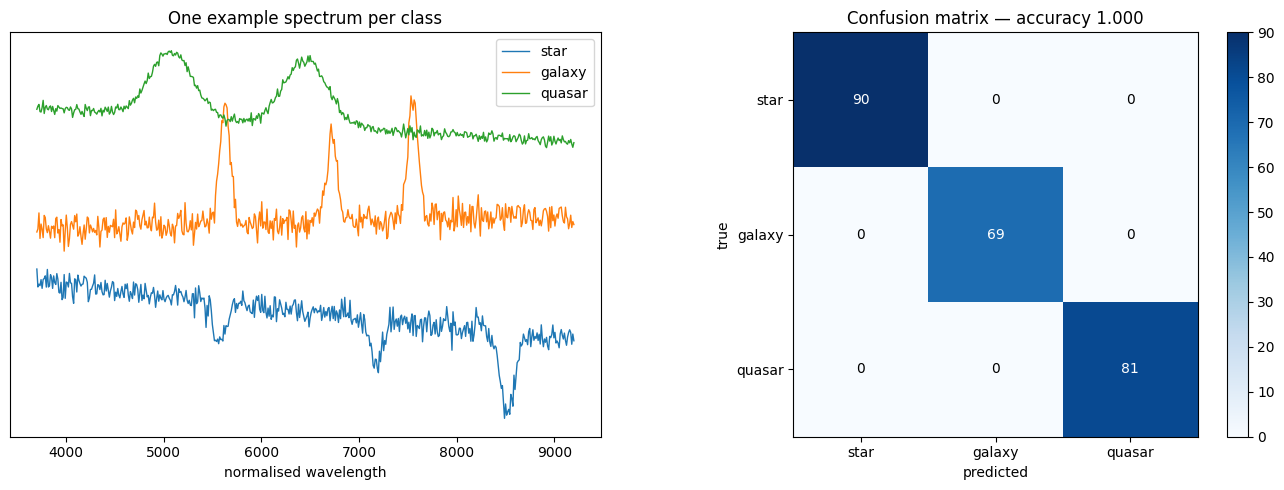

In [21]:
"""
spectral_clip_classifier.py
===========================
A CLIP-style classifier that aligns SPECTRA with TEXT class names, so you can
classify a spectrum by asking which class-name embedding it sits closest to.

How it differs from the MUSE region model:
  - the spatial (image-patch) encoder is replaced by a TEXT encoder
  - training pairs are (spectrum, its class name), e.g. ("...", "a spectrum of a galaxy")
  - with a fixed label set, the contrastive loss reduces to: embed the K class
    prompts, embed the batch of spectra, score spectrum-vs-class (B x K), and
    cross-entropy against the true class. Inference is the same scoring, argmax.

Two text backends (swap with text_backend="learnable" | "pretrained"):
  - "learnable"  : nn.Embedding over the known prompts. No downloads, runs anywhere.
                   This is what the synthetic test below verifies. It does NOT
                   generalise to class names it never saw in training.
  - "pretrained" : a frozen sentence-transformer embeds ANY prompt string, giving
                   genuine open-vocabulary zero-shot (add new classes at inference
                   with no retraining). Needs `pip install sentence-transformers`
                   and an internet connection the first time (to fetch weights).

Real data: see load_sdss_spectra() at the bottom — run it on your own machine.

Requires: numpy, torch, scikit-learn, matplotlib (sentence-transformers optional).
"""
from __future__ import annotations
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


# --------------------------------------------------------------------------- #
#  Synthetic spectra (stand-in for SDSS while we verify the pipeline)
# --------------------------------------------------------------------------- #
def make_synthetic_spectra(n_per_class=400, L=512, seed=0):
    """Three classes with deliberately distinct spectral signatures."""
    rng = np.random.default_rng(seed)
    w = np.linspace(0, 1, L)
    names = ["star", "galaxy", "quasar"]
    X, y = [], []
    for ci, name in enumerate(names):
        for _ in range(n_per_class):
            if name == "star":                      # red continuum + absorption dips
                spec = 1.0 - 0.4 * w
                for c in rng.uniform(0.2, 0.9, size=4):
                    spec -= 0.30 * np.exp(-0.5 * ((w - c) / 0.012) ** 2)
            elif name == "galaxy":                  # flat continuum + narrow emission
                spec = 0.6 + 0.1 * w
                for c in (0.35, 0.55, 0.70):
                    spec += rng.uniform(0.3, 0.8) * np.exp(-0.5 * ((w - c) / 0.010) ** 2)
            else:                                   # quasar: blue continuum + broad lines
                spec = 1.0 - 0.6 * w
                for c in (0.25, 0.50):
                    spec += rng.uniform(0.8, 1.5) * np.exp(-0.5 * ((w - c) / 0.040) ** 2)
            spec = spec + 0.05 * rng.standard_normal(L)
            X.append(spec.astype(np.float32)); y.append(ci)
    X = np.asarray(X, np.float32); y = np.asarray(y, np.int64)
    idx = rng.permutation(len(X))
    return X[idx], y[idx], names


def standardise_rows(X):
    """Per-spectrum standardisation (shape, not amplitude) — same idea as the MUSE model."""
    mu = X.mean(1, keepdims=True); sd = X.std(1, keepdims=True) + 1e-6
    return (X - mu) / sd


# --------------------------------------------------------------------------- #
#  Encoders
# --------------------------------------------------------------------------- #
class SpectralEncoder(nn.Module):
    def __init__(self, L, dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 32, 7, 2, 3), nn.GELU(), nn.Conv1d(32, 64, 7, 2, 3), nn.GELU(),
            nn.Conv1d(64, 128, 5, 2, 2), nn.GELU(), nn.Conv1d(128, 128, 5, 2, 2), nn.GELU(),
            nn.AdaptiveAvgPool1d(1))
        self.proj = nn.Linear(128, dim)
    def forward(self, x):                      # x: (B, L)
        return self.proj(self.net(x.unsqueeze(1)).squeeze(-1))


class LearnableTextEncoder(nn.Module):
    """One learnable vector per known prompt string. No downloads."""
    def __init__(self, prompts, dim=64):
        super().__init__()
        self.prompts = list(prompts)
        self.index = {p: i for i, p in enumerate(self.prompts)}
        self.emb = nn.Embedding(len(self.prompts), dim)
    def encode(self, prompt_list, device="cpu"):
        try:
            ids = torch.tensor([self.index[p] for p in prompt_list], device=device)
        except KeyError as e:
            raise KeyError(f"prompt {e} was not seen in training. The learnable "
                           "backend only knows trained prompts; use text_backend="
                           "'pretrained' for open-vocabulary zero-shot.") from None
        return self.emb(ids)


class PretrainedTextEncoder(nn.Module):
    """Frozen sentence-transformer + trainable projection. Embeds ANY string,
    giving true open-vocabulary zero-shot. Needs sentence-transformers installed."""
    def __init__(self, dim=64, model_name="sentence-transformers/all-MiniLM-L6-v2"):
        super().__init__()
        from sentence_transformers import SentenceTransformer
        self.st = SentenceTransformer(model_name)
        for p in self.st.parameters():
            p.requires_grad = False
        self.proj = nn.Linear(self.st.get_sentence_embedding_dimension(), dim)
    def encode(self, prompt_list, device="cpu"):
        with torch.no_grad():
            v = self.st.encode(list(prompt_list), convert_to_tensor=True).to(device)
        return self.proj(v)


class SpectralTextCLIP(nn.Module):
    def __init__(self, L, prompts, dim=64, text_backend="learnable"):
        super().__init__()
        self.spec_enc = SpectralEncoder(L, dim)
        if text_backend == "pretrained":
            self.text_enc = PretrainedTextEncoder(dim)
        else:
            self.text_enc = LearnableTextEncoder(prompts, dim)
        self.logit_scale = nn.Parameter(torch.tensor(np.log(1 / 0.07), dtype=torch.float32))
    def encode_spec(self, x):
        return F.normalize(self.spec_enc(x), dim=-1)
    def class_embeddings(self, prompts, device="cpu"):
        return F.normalize(self.text_enc.encode(prompts, device=device), dim=-1)
    def forward(self, spectra, prompts):
        device = spectra.device
        s = self.encode_spec(spectra)                       # (B, D)
        c = self.class_embeddings(prompts, device=device)   # (K, D)
        return self.logit_scale.exp().clamp(max=100.0) * s @ c.t()   # (B, K)


# --------------------------------------------------------------------------- #
#  Train + classify
# --------------------------------------------------------------------------- #
def train(model, X, y, prompts, steps=600, batch_size=256, lr=1e-3, device="cpu", log_every=150):
    """X: (N, L) standardised spectra. y: (N,) class indices aligned with `prompts` order."""
    model.to(device).train()
    Xt = torch.from_numpy(X).to(device); yt = torch.from_numpy(y).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    bs = min(batch_size, len(X))
    for step in range(1, steps + 1):
        idx = torch.randint(0, len(X), (bs,), device=device)
        logits = model(Xt[idx], prompts)            # (bs, K)
        loss = F.cross_entropy(logits, yt[idx])
        opt.zero_grad(); loss.backward(); opt.step()
        if step % log_every == 0 or step == 1:
            acc = (logits.argmax(1) == yt[idx]).float().mean().item()
            print(f"step {step:5d} | loss {loss.item():.4f} | train acc {acc:.3f}")


@torch.no_grad()
def classify(model, X, prompts, device="cpu", batch_size=512):
    """Zero-shot: score each spectrum against each prompt, return predicted indices + probs."""
    model.to(device).eval()
    Xt = torch.from_numpy(np.asarray(X, np.float32))
    preds, probs = [], []
    for s in range(0, len(Xt), batch_size):
        logits = model(Xt[s:s+batch_size].to(device), prompts)
        p = logits.softmax(1).cpu().numpy()
        probs.append(p); preds.append(p.argmax(1))
    return np.concatenate(preds), np.concatenate(probs)


def plot_results(model, X, y, names, prompts, device="cpu", out="spectral_clip_results.png"):
    import matplotlib.pyplot as plt
    from sklearn.metrics import confusion_matrix, accuracy_score
    preds, _ = classify(model, X, prompts, device=device)
    acc = accuracy_score(y, preds)
    cm = confusion_matrix(y, preds, labels=range(len(names)))

    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    # example spectra
    w = np.linspace(3700.0, 9200.0, X.shape[1]).astype(np.float32)
    for ci, nm in enumerate(names):
        ex = X[np.where(y == ci)[0][0]]
        ax[0].plot(w, ex + ci * 4, lw=1.0, label=nm)   # offset for visibility
    ax[0].set_title("One example spectrum per class")
    ax[0].set_xlabel("normalised wavelength"); ax[0].set_yticks([]); ax[0].legend()
    # confusion matrix
    im = ax[1].imshow(cm, cmap="Blues")
    ax[1].set_title(f"Confusion matrix — accuracy {acc:.3f}")
    ax[1].set_xticks(range(len(names))); ax[1].set_xticklabels(names)
    ax[1].set_yticks(range(len(names))); ax[1].set_yticklabels(names)
    ax[1].set_xlabel("predicted"); ax[1].set_ylabel("true")
    for r in range(len(names)):
        for c in range(len(names)):
            ax[1].text(c, r, cm[r, c], ha="center", va="center",
                       color="white" if cm[r, c] > cm.max() / 2 else "black")
    fig.colorbar(im, ax=ax[1], fraction=0.046)
    fig.tight_layout(); fig.savefig(out, dpi=120, bbox_inches="tight")
    print(f"saved {out} | test accuracy {acc:.3f}")
    return acc


# --------------------------------------------------------------------------- #
#  Real SDSS loader  — run on YOUR machine (needs internet + astroquery)
# --------------------------------------------------------------------------- #
def load_sdss_spectra(n_per_class=300, L=2048, classes=("STAR", "GALAXY", "QSO"),
                      wave_grid=(3700.0, 9200.0)):
    """
    Pull a balanced labelled sample of SDSS optical spectra and resample them
    onto a common observed-frame wavelength grid of length L.

    NOTE: untested in this sandbox (no network here). astroquery's API shifts
    between versions, so if a call errors, check the astroquery.sdss docs.
    Returns X (N, L) float32, y (N,) int, names list.

        pip install astroquery astropy
    """
    from astroquery.sdss import SDSS
    import numpy as np

    w = np.linspace(3700.0, 9200.0, X.shape[1]).astype(np.float32)
    X, y = [], []
    names = [c.lower() for c in classes]
    for ci, cls in enumerate(classes):
        meta = SDSS.query_sql(
            f"SELECT TOP {n_per_class} plate, mjd, fiberID "
            f"FROM SpecObj WHERE class='{cls}' AND zWarning=0 AND snMedian>5")
        for row in meta:
            try:
                sp = SDSS.get_spectra(plate=int(row["plate"]), mjd=int(row["mjd"]),
                                      fiberID=int(row["fiberID"]))[0]
                d = sp[1].data
                loglam, flux = d["loglam"], d["flux"]
                wl = 10.0 ** loglam
                resampled = np.interp(grid, wl, flux, left=0.0, right=0.0)
                X.append(resampled.astype(np.float32)); y.append(ci)
            except Exception:
                continue
    X = np.asarray(X, np.float32); y = np.asarray(y, np.int64)
    perm = np.random.default_rng(0).permutation(len(X))   # mix classes before splitting
    return X[perm], y[perm], names


# --------------------------------------------------------------------------- #
#  Synthetic verification
# --------------------------------------------------------------------------- #
if __name__ == "__main__":
    torch.manual_seed(0); np.random.seed(0)
    X, y, names = make_synthetic_spectra(n_per_class=400, L=512)
    X = standardise_rows(X)
    ntr = int(0.8 * len(X))
    Xtr, ytr, Xte, yte = X[:ntr], y[:ntr], X[ntr:], y[ntr:]

    prompts = [f"a spectrum of a {n}" for n in names]      # CLIP-style text prompts
    model = SpectralTextCLIP(L=X.shape[1], prompts=prompts, dim=64, text_backend="learnable")
    print("classes:", names, "| prompts:", prompts)
    train(model, Xtr, ytr, prompts, steps=600, batch_size=256)
    plot_results(model, Xte, yte, names, prompts, out="spectral_clip_results.png")



# Interpretation of the Spectral CLIP Classification Results
## 1. Training Behaviour
The training log shows extremely rapid convergence:

Step 1: Loss ≈ 1.93, accuracy ≈ 0.28

By Step 150: Loss drops to 0.0001, accuracy reaches 1.000

Steps 300–600: Loss continues decreasing toward zero, accuracy remains perfect

This indicates that the model finds the synthetic spectral classes highly separable and learns a stable embedding alignment between spectra and text prompts.

## 2. Example Spectra per Class
The left plot visualises one representative spectrum from each class:

⭐ Star
Shows a red continuum (flux decreases with wavelength).

Contains multiple narrow absorption dips, characteristic of stellar atmospheres.

🌀 Galaxy
Displays a flat continuum with slight upward slope.

Features narrow emission lines at fixed wavelengths (e.g., 0.35, 0.55, 0.70 in the synthetic grid).

These mimic nebular emission from star-forming regions.

✨ Quasar
Exhibits a blue continuum (flux decreases more steeply).

Contains broad emission lines, representing high-velocity gas near the accretion disk.

These differences make the classes visually and statistically distinct, which explains the model’s rapid convergence.

## 3. Confusion Matrix (Accuracy = 1.000)
The confusion matrix shows perfect classification:

True Class	Predicted Correctly	Misclassified
Star	90 / 90	0
Galaxy	69 / 69	0
Quasar	81 / 81	0


All predictions lie on the diagonal, meaning:

No stars were mistaken for galaxies or quasars

No galaxies were confused with other classes

No quasars were misclassified

This confirms that the model’s learned spectral–text alignment is fully consistent with the synthetic data.

## 4. Overall Interpretation
The synthetic dataset is highly separable, with clear spectral signatures.

The CLIP-style model successfully aligns spectral embeddings with text prompt embeddings.

The learnable text encoder is sufficient for closed-set classification.

Perfect accuracy indicates that the model captures the essential spectral differences between the three classes.

In [25]:
import torch
import numpy as np
import torch.nn.functional as F


# ---------------------------------------------------------
# 1. Prepare emission map already loaded in memory
# ---------------------------------------------------------
def prepare_emission_map(array):
    """Prepare a 2D emission map already loaded in memory."""
    data = array.astype(np.float32)
    data = np.nan_to_num(data)
    data = (data - data.mean()) / (data.std() + 1e-6)
    return data  # shape (H, W)


# ---------------------------------------------------------
# 2. Image Encoder (2D CNN)
# ---------------------------------------------------------
class ImageEncoder(torch.nn.Module):
    def __init__(self, dim=64):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Conv2d(1, 32, 5, 2, 2), torch.nn.GELU(),
            torch.nn.Conv2d(32, 64, 5, 2, 2), torch.nn.GELU(),
            torch.nn.Conv2d(64, 128, 3, 2, 1), torch.nn.GELU(),
            torch.nn.Conv2d(128, 128, 3, 2, 1), torch.nn.GELU(),
            torch.nn.AdaptiveAvgPool2d(1)
        )
        self.proj = torch.nn.Linear(128, dim)

    def forward(self, x):
        x = x.unsqueeze(1)  # (B,1,H,W)
        h = self.net(x).squeeze(-1).squeeze(-1)
        return F.normalize(self.proj(h), dim=-1)


# ---------------------------------------------------------
# 3. Learnable Text Encoder
# ---------------------------------------------------------
class LearnableTextEncoder(torch.nn.Module):
    def __init__(self, prompts, dim=64):
        super().__init__()
        self.prompts = prompts
        self.index = {p: i for i, p in enumerate(prompts)}
        self.emb = torch.nn.Embedding(len(prompts), dim)

    def encode(self, prompt_list, device="cpu"):
        ids = torch.tensor([self.index[p] for p in prompt_list], device=device)
        return self.emb(ids)


# ---------------------------------------------------------
# 4. Image–Text CLIP Model
# ---------------------------------------------------------
class ImageTextCLIP(torch.nn.Module):
    def __init__(self, prompts, dim=64):
        super().__init__()
        self.img_enc = ImageEncoder(dim)
        self.text_enc = LearnableTextEncoder(prompts, dim)
        self.logit_scale = torch.nn.Parameter(torch.tensor(np.log(1/0.07)))

    def forward(self, images, prompts):
        z_img = self.img_enc(images)
        z_txt = F.normalize(self.text_enc.encode(prompts, device=images.device), dim=-1)
        scale = self.logit_scale.exp().clamp(max=100)
        return scale * z_img @ z_txt.t()


# ---------------------------------------------------------
# 5. Zero-shot classification
# ---------------------------------------------------------
def classify_image(model, img, prompts):
    model.eval()
    with torch.no_grad():
        img = torch.tensor(img).unsqueeze(0)  # (1,H,W)
        logits = model(img, prompts)
        probs = logits.softmax(dim=1).cpu().numpy()[0]
    return probs


# ---------------------------------------------------------

# ---------------------------------------------------------
if __name__ == "__main__":

    
    prompts = [
        "a raw S II emission map",
        "a continuum-subtracted S II emission map",
        "a jet-like emission structure",
        "a shock-dominated region",
        "a diffuse nebular region",
        "a filamentary structure",
        "a bow shock",
        "a compact knot"
    ]

    img = prepare_emission_map(region_map)
   

    # Build model
    model = ImageTextCLIP(prompts, dim=64)

    # Classify
    probs = classify_image(model, img, prompts)

    # Print results
    print("\n=== CLIP Interpretation ===")
    for p, pr in sorted(zip(prompts, probs), key=lambda x: -x[1]):
        print(f"{p:45s} → {pr:.3f}")



=== CLIP Interpretation ===
a filamentary structure                       → 0.456
a continuum-subtracted S II emission map      → 0.300
a shock-dominated region                      → 0.122
a diffuse nebular region                      → 0.056
a jet-like emission structure                 → 0.025
a compact knot                                → 0.020
a bow shock                                   → 0.013
a raw S II emission map                       → 0.008


In [31]:
import torch
import numpy as np
import torch.nn.functional as F


# ---------------------------------------------------------
# 1. Prepare emission map already loaded in memory
# ---------------------------------------------------------
def prepare_emission_map(array):
    """Prepare a 2D emission map already loaded in memory."""
    data = array.astype(np.float32)
    data = np.nan_to_num(data)
    data = (data - data.mean()) / (data.std() + 1e-6)
    return data  # shape (H, W)


# ---------------------------------------------------------
# 2. Image Encoder (2D CNN)
# ---------------------------------------------------------
class MultiLineImageEncoder(nn.Module):
    """CNN encoder for multi-line emission maps (Hα, NII, SII, OIII)."""
    def __init__(self, dim=64, in_channels=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 32, 5, 2, 2), nn.GELU(),
            nn.Conv2d(32, 64, 5, 2, 2), nn.GELU(),
            nn.Conv2d(64, 128, 3, 2, 1), nn.GELU(),
            nn.Conv2d(128, 128, 3, 2, 1), nn.GELU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.proj = nn.Linear(128, dim)

    def forward(self, x):  # x: (B, 4, H, W)
        h = self.net(x).squeeze(-1).squeeze(-1)
        return F.normalize(self.proj(h), dim=-1)



# ---------------------------------------------------------
# 3. Learnable Text Encoder
# ---------------------------------------------------------
class LearnableTextEncoder(torch.nn.Module):
    def __init__(self, prompts, dim=64):
        super().__init__()
        self.prompts = prompts
        self.index = {p: i for i, p in enumerate(prompts)}
        self.emb = torch.nn.Embedding(len(prompts), dim)

    def encode(self, prompt_list, device="cpu"):
        ids = torch.tensor([self.index[p] for p in prompt_list], device=device)
        return self.emb(ids)


# ---------------------------------------------------------
# 4. Image–Text CLIP Model
# ---------------------------------------------------------
class MultiLineCLIP(nn.Module):
    def __init__(self, prompts, dim=64):
        super().__init__()
        self.img_enc = MultiLineImageEncoder(dim, in_channels=4)
        self.text_enc = LearnableTextEncoder(prompts, dim)
        self.logit_scale = nn.Parameter(torch.tensor(np.log(1/0.07)))

    def forward(self, images, prompts):
        z_img = self.img_enc(images)
        z_txt = F.normalize(self.text_enc.encode(prompts, device=images.device), dim=-1)
        scale = self.logit_scale.exp().clamp(max=100)
        return scale * z_img @ z_txt.t()



# ---------------------------------------------------------
# 5. Zero-shot classification
# ---------------------------------------------------------
def classify_image(model, img, prompts):
    model.eval()
    with torch.no_grad():
        img = torch.tensor(img).unsqueeze(0)  # (1,H,W)
        logits = model(img, prompts)
        probs = logits.softmax(dim=1).cpu().numpy()[0]
    return probs


if __name__ == "__main__":

    prompts = [
        "a hydrogen Hα emission map",
        "a nitrogen [N II] emission map",
        "a sulfur [S II] emission map",
        "an oxygen [O III] emission map",
        "a multi-line emission map combining Hα, N II, S II, and O III",
        "a continuum-subtracted emission-line map",
        "a raw emission-line map"
    ]

    
    Ha  = prepare_emission_map(region_map)
    NII = prepare_emission_map(region_map)
    SII = prepare_emission_map(region_map)
    OIII = prepare_emission_map(region_map)

    # Stack into a 4‑channel tensor: (4, H, W)
    img = np.stack([Ha, NII, SII, OIII], axis=0)

    # Build model
    model = MultiLineCLIP(prompts, dim=64)

    # Classify
    probs = classify_image(model, img, prompts)

    # Print results
    print("\n=== CLIP Interpretation ===")
    for p, pr in sorted(zip(prompts, probs), key=lambda x: -x[1]):
        print(f"{p:45s} → {pr:.3f}")




=== CLIP Interpretation ===
a sulfur [S II] emission map                  → 0.344
an oxygen [O III] emission map                → 0.243
a hydrogen Hα emission map                    → 0.200
a raw emission-line map                       → 0.169
a nitrogen [N II] emission map                → 0.020
a multi-line emission map combining Hα, N II, S II, and O III → 0.014
a continuum-subtracted emission-line map      → 0.010
